# Day 24 – Stochastic & Mini-batch Gradient Descent and Polynomial Regression


- Explain Batch, Stochastic, and Mini-batch Gradient Descent.
- Understand why learning-rate schedules are used.
- Compare the trade-offs of different gradient descent methods.
- Understand Polynomial Regression and polynomial features.
- Visualize underfitting, good fit, and overfitting.


## Import Libraries

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)


# 1. What is Gradient Descent?

Gradient Descent updates model parameters to reduce prediction error.

Update rule:

\[
\theta_{new} = \theta_{old} - \eta \nabla J(\theta)
\]

- **θ** = model parameters
- **η** = learning rate
- **∇J(θ)** = gradient of the cost function

Think of it as walking downhill to reach the lowest point of a valley.


# 2. Create a Simple Linear Dataset

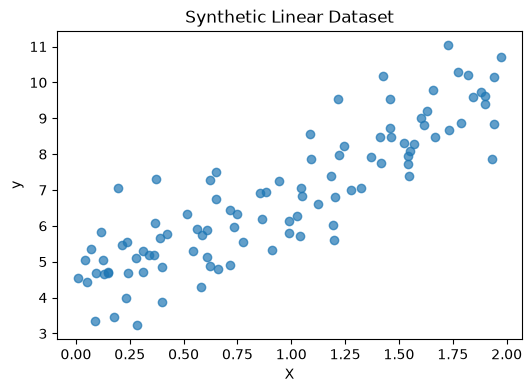

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Linear Dataset")
plt.show()


The true relationship is approximately:

\[
y = 4 + 3x + \text{noise}
\]


# 3. Batch Gradient Descent

- Uses **all training samples** to compute one update.
- Stable and smooth.
- Slow for large datasets.

| Method | Samples per update |
|---|---|
| Batch GD | All samples |
| SGD | 1 sample |
| Mini-batch GD | Small batch (e.g., 32) |


# 4. Stochastic Gradient Descent (SGD)

SGD updates parameters using **one random sample at a time**.


In [35]:
sgd = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    eta0=0.1,
    learning_rate="constant",
    random_state=42
)

sgd.fit(X, y.ravel())

print("Intercept:", sgd.intercept_)
print("Coefficient:", sgd.coef_)


Intercept: [4.1215872]
Coefficient: [2.68566488]


### Prediction Line

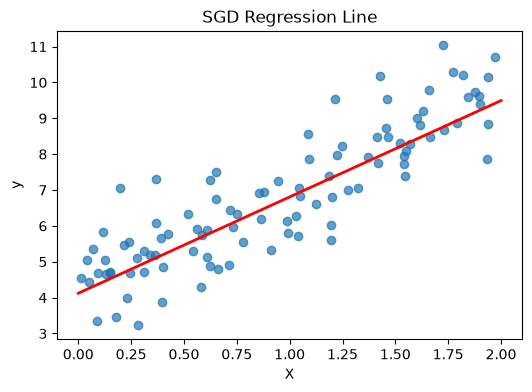

In [36]:
X_new = np.array([[0], [2]])
y_pred = sgd.predict(X_new)

plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.7)
plt.plot(X_new, y_pred, "r-", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("SGD Regression Line")
plt.show()


### SGD Intuition

- Fast updates
- Low memory usage
- Noisy path toward the minimum
- Works well for very large datasets


# 5. Learning-Rate Schedule

A common schedule decreases the learning rate over time:

\[
\eta_t = \frac{\eta_0}{1 + kt}
\]

Large steps at the beginning, smaller steps later.


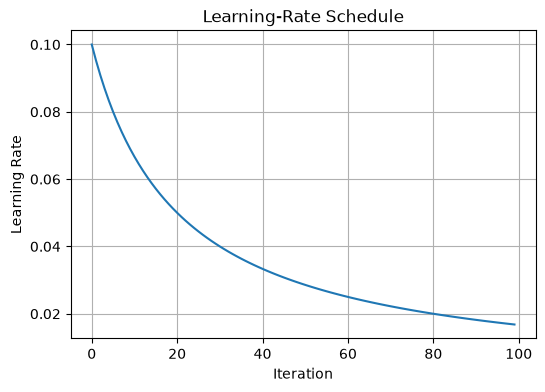

In [37]:
eta0 = 0.1
k = 0.05
t = np.arange(0, 100)

eta_t = eta0 / (1 + k * t)

plt.figure(figsize=(6,4))
plt.plot(t, eta_t)
plt.xlabel("Iteration")
plt.ylabel("Learning Rate")
plt.title("Learning-Rate Schedule")
plt.grid(True)
plt.show()


### Why reduce the learning rate?

- Large learning rate → may overshoot.
- Small learning rate → slow learning.
- Decay schedule → fast start and stable finish.


# 6. Mini-batch Gradient Descent

Mini-batch GD uses a small batch of samples for each update.

Typical batch sizes:

- 16
- 32
- 64
- 128


In [38]:
batch_size = 16
n_batches = int(np.ceil(len(X) / batch_size))

print("Total samples:", len(X))
print("Batch size:", batch_size)
print("Number of batches:", n_batches)


Total samples: 100
Batch size: 16
Number of batches: 7


Mini-batch GD is usually preferred in deep learning because it balances:

- speed,
- stability,
- and hardware efficiency.


# 7. Batch vs SGD vs Mini-batch

| Feature | Batch GD | SGD | Mini-batch GD |
|---|---|---|---|
| Speed | Slow | Fast | Fast |
| Memory | High | Low | Medium |
| Noise | Low | High | Medium |
| Stability | High | Low | Medium–High |
| Large datasets | Poor | Excellent | Excellent |


# 8. Polynomial Regression

Suppose data follows a curve instead of a straight line.


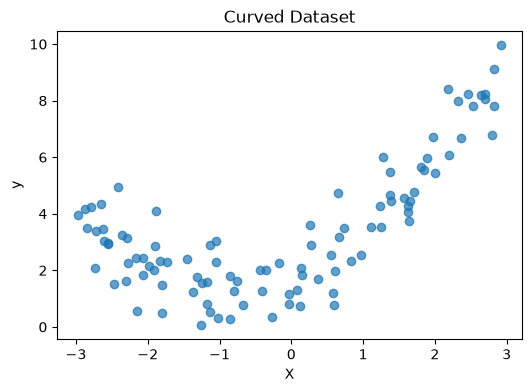

In [39]:
m = 100
X_poly = 6 * np.random.rand(m, 1) - 3
y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.randn(m, 1)

plt.figure(figsize=(6,4))
plt.scatter(X_poly, y_poly, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Curved Dataset")
plt.show()


A straight line cannot fit this data well.

Polynomial Regression adds new features such as **x²**:

\[
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2
\]


# 9. Train a Polynomial Regression Model

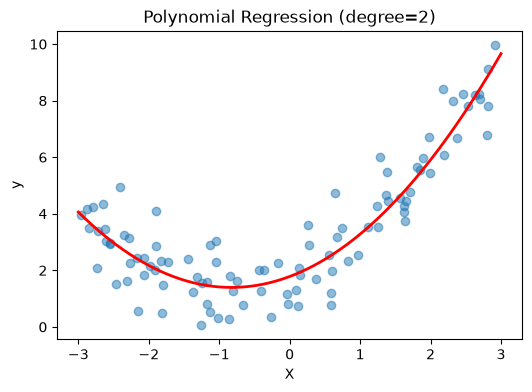

In [40]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

poly_model.fit(X_poly, y_poly)

X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_plot = poly_model.predict(X_plot)

plt.figure(figsize=(6,4))
plt.scatter(X_poly, y_poly, alpha=0.5)
plt.plot(X_plot, y_plot, "r", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (degree=2)")
plt.show()


The red curve now follows the data much better than a straight line.


# 10. Underfitting vs Good Fit vs Overfitting

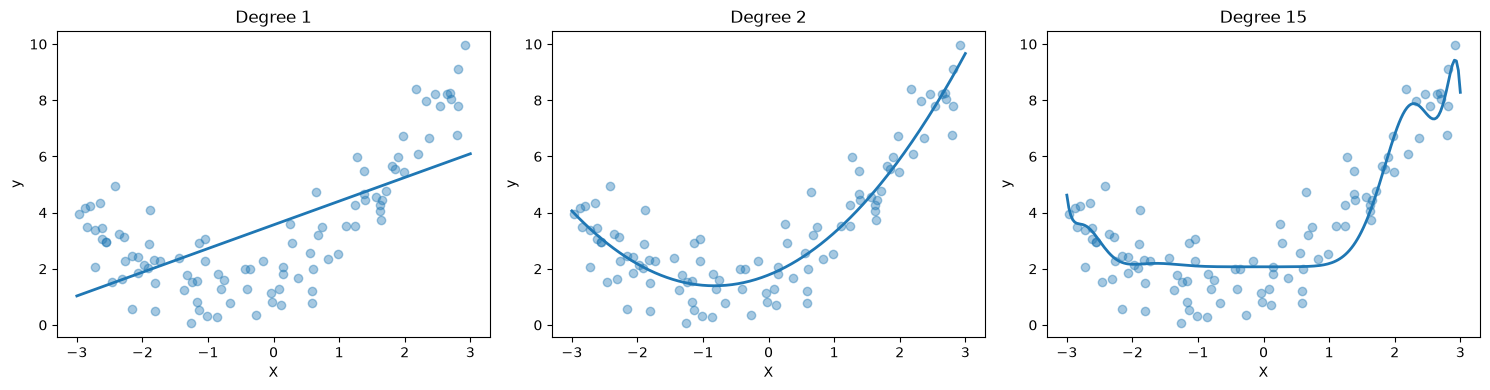

In [41]:
degrees = [1, 2, 15]

plt.figure(figsize=(15,4))

for i, degree in enumerate(degrees, 1):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    model.fit(X_poly, y_poly)
    y_curve = model.predict(X_plot)

    plt.subplot(1,3,i)
    plt.scatter(X_poly, y_poly, alpha=0.4)
    plt.plot(X_plot, y_curve, linewidth=2)
    plt.title(f"Degree {degree}")
    plt.xlabel("X")
    plt.ylabel("y")

plt.tight_layout()
plt.show()


### Interpretation

- **Degree 1:** Underfitting (too simple)
- **Degree 2:** Good fit
- **Degree 15:** Overfitting (too complex)


# 11. Compare Training Error

In [ ]:
for degree in [1, 2, 15]:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    model.fit(X_poly, y_poly)
    pred = model.predict(X_poly)
    mse = mean_squared_error(y_poly, pred)
    print(f"Degree {degree:2d} -> Training MSE: {mse:.3f}")


Degree  1 -> Training MSE: 3.025
Degree  2 -> Training MSE: 0.777
Degree 15 -> Training MSE: 1.117


: 

Notice that a very high degree may achieve very low training error, but that does **not** guarantee good performance on unseen data.


# 12. Key Takeaways

## SGD

- One sample per update
- Fast
- Memory efficient
- Noisy updates

## Mini-batch GD

- Small batch per update
- Smoother than SGD
- Fast and practical
- Commonly used in deep learning

## Learning-rate Schedule

- Start larger
- Reduce gradually
- Helps convergence

## Polynomial Regression

- Adds polynomial features
- Models curved relationships
- High degree may overfit


# 13. Quick Revision Questions & Interview Summary

1. Why is SGD faster than Batch GD?
   - Because it updates parameters using one training sample at a time instead of the entire dataset, so each step is much cheaper.

2. What problem does a learning-rate schedule solve?
   - It helps the model converge smoothly by starting with a larger step size and gradually reducing it to avoid overshooting and stabilize training.

3. Why is Mini-batch GD preferred in practice?
   - It is faster than Batch GD, less noisy than SGD, and often runs more efficiently on hardware while providing good convergence.

4. What feature is added in quadratic regression?
   - A quadratic term such as x² (and sometimes higher powers like x³) is added so the model can learn curved relationships.

5. What is overfitting?
   - Overfitting happens when a model is too complex and learns the training data too closely, including noise, so it performs poorly on unseen data.

**Batch GD** uses all data and is stable but slow.  
**SGD** uses one sample and is fast but noisy.  
**Mini-batch GD** uses small batches and balances speed and stability.  
A **learning-rate schedule** gradually decreases the step size for better convergence.  
**Polynomial Regression** creates features such as x² and x³ so a linear model can learn curved patterns; very high degrees may overfit.
